# BERTOPIC

In [2]:
#import packages

import pandas as pd 
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer #for multilingual data
import re
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
df = pd.read_csv('/Users/market/Desktop/thesis_project/data/df_new2.csv')



## ЛЕММАТИЗАЦИЯ ручная

In [4]:
def deep_clean_kazakh(text):
    if not isinstance(text, str):
        return ""
    
    # Приводим к нижнему регистру и убираем пунктуацию, чтобы не мешала границам слов
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    
    # Список окончаний: от длинных к коротким (важно для корректного срабатывания)
    # Добавил также специфические суффиксы принадлежности (ым, ың и т.д.)
    pattern = r'(лар|лер|дар|дер|тар|тер|дың|дің|тың|тің|ның|нің|лық|лік|дық|дік|тық|тік|да|де|та|те|қа|ке|ға|ге|ны|ні|ты|ті|дан|ден|тан|тен|нан|нен|мен|бен|пен|ым|ім|ың|ің|ы|і|ын)\b'
    
    words = text.split()
    cleaned_words = []
    
    for word in words:
        # Прогоняем слово через цикл удаления суффиксов (до 3-х слоев)
        for _ in range(3):
            new_word = re.sub(pattern, '', word)
            if new_word == word or len(new_word) < 3: # Останавливаемся, если корень стал слишком коротким
                break
            word = new_word
        cleaned_words.append(word)
    
    return " ".join(cleaned_words)


## Стоп слова и очистка

In [5]:
# 1. Загрузка стоп-слов правильно
# Если в файле нет заголовка, используем header=None и указываем имя столбца
df_stop = pd.read_csv('/Users/market/Desktop/thesis_project/stopwords/kazakh_stopwords.txt', header=None, names=['word'])
kz_stopwords = df_stop['word'].astype(str).tolist()

# 2. Очистка самих стоп-слов
# Мы применяем ту же функцию, что и для текстов, чтобы совпали "корни"
cleaned_stopwords = [deep_clean_kazakh(w) for w in kz_stopwords]
cleaned_stopwords = list(set(filter(None, cleaned_stopwords))) # убираем пустые и дубли


Обучаем модель не на подсетах по годам, ибо по каждому году ты запускаешь отдельную модель - долго

лучше на всех данных, а потом просто смотришь распределение по годам

## BERTopic with bigrams 


In [10]:

#1
vectorizer_model_bigrams = CountVectorizer(
    preprocessor=deep_clean_kazakh, 
    stop_words=cleaned_stopwords, # Теперь они совпадут с результатами очистки текста
    ngram_range=(1, 2)
)

model_bigrams = BERTopic(
    embedding_model=SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"),
    vectorizer_model=vectorizer_model_bigrams,
    calculate_probabilities=True, # ОБЯЗАТЕЛЬНО для регрессии на вероятностях
    verbose=True
)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# 3. Запуск обучения (Fit & Transform)
docs = df['title'].to_list()
topics, probs = model_bigrams.fit_transform(docs)

# 4. Добавляем результаты в ваш основной датафрейм
df['topic'] = topics

# 5. Подготовка данных для визуализации (группировка по годам)
df_all = (
    df[df['topic'] != -1] 
    .groupby(['topic', 'year'])
    .size()
    .reset_index(name='Count')
)

2026-04-18 04:02:15,384 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

2026-04-18 04:02:21,511 - BERTopic - Embedding - Completed ✓
2026-04-18 04:02:21,512 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-18 04:02:27,791 - BERTopic - Dimensionality - Completed ✓
2026-04-18 04:02:27,800 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-18 04:02:28,084 - BERTopic - Cluster - Completed ✓
2026-04-18 04:02:28,100 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-18 04:02:28,271 - BERTopic - Representation - Completed ✓


In [14]:
# 1. Создаем DataFrame из матрицы вероятностей
# Каждая колонка — это вероятность принадлежности к теме (Topic 0, Topic 1, ...)
topic_names = [f"topic_prob_{i}" for i in range(probs.shape[1])]
df_probs = pd.DataFrame(probs, columns=topic_names)

# 2. Объединяем вероятности с вашим основным датафреймом df
# Теперь в каждой строке (фетве) есть и её текст, и вероятности всех тем
df_final = pd.concat([df.reset_index(drop=True), df_probs], axis=1)

In [16]:
# 1. Получаем таблицу с ключевыми словами для всех тем
topic_info = model_bigrams.get_topic_info()

# Создаем словарь: Номер темы -> Топ-5 ключевых слов
# Это позволит нам сохранить "смысл" темы прямо в названии колонки или в отдельной таблице
topic_mapping = {
    row['Topic']: ", ".join([w[0] for w in model_bigrams.get_topic(row['Topic'])[:5]])
    for index, row in topic_info.iterrows() if row['Topic'] != -1
}

# 2. Создаем DataFrame с вероятностями
topic_prob_cols = [f"topic_prob_{i}" for i in range(probs.shape[1])]
df_probs = pd.DataFrame(probs, columns=topic_prob_cols)

# 3. Добавляем в df_probs информацию о ключевых словах (в виде метаданных или отдельной строки)
# Но для CSV удобнее всего сохранить отдельный файл-справочник
df_keywords = pd.DataFrame(list(topic_mapping.items()), columns=['Topic_ID', 'Keywords'])
df_keywords.to_csv("/Users/market/Desktop/thesis_project/data/topic_dictionary.csv", index=False)

# 4. Объединяем основной DF с вероятностями
df_final = pd.concat([df.reset_index(drop=True), df_probs], axis=1)

# 5. Сохраняем финальный датасет для регрессии
df_final.to_csv("/Users/market/Desktop/thesis_project/data/fatwas_with_probabilities.csv", index=False)

In [9]:
model_bigrams.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1036,-1_күн_талақ_бала_намазд,"[күн, талақ, бала, намазд, күйеу, дәрет, хайыз...",[ауызды уақытынан кешіктіріп ашқан болса ораза...
1,0,116,0_түшкірген_бөтен_шай сенбейтін_қабылдаған,"[түшкірген, бөтен, шай сенбейтін, қабылдаған, ...",[сәләфиттердің айтысына қарағанда имам әшғари ...
2,1,110,1_ақша_қарыз_кредит_сатып,"[ақша, қарыз, кредит, сатып, зекет, зат, жұмыс...","[құмар ойынынан ұтқан ақшаны не істеу керек, т..."
3,2,90,2_түсін_мек_тырнақ_екеу,"[түсін, мек, тырнақ, екеу, риязат, ихрамсыз, а...",[жатын бөлмеде айна тұрса періште кірмейді дег...
4,3,72,3_үтір_оқымай_арақ_христиан,"[үтір, оқымай, арақ, христиан, қаза, сүре, жам...",[сәләфилер бесін намазының төрт рәкәғат сүннет...
5,4,59,4_ғұсыл_ат қою_ат_уәжіп,"[ғұсыл, ат қою, ат, уәжіп, талақ, орнына, ракә...",[ғұсыл алатын суға қолды батырып көрсе ол суме...
6,5,57,5_отырыс_сәлем_сәждесін_сәһу сәждесін,"[отырыс, сәлем, сәждесін, сәһу сәждесін, тұрға...",[сәһу сәждесін жасау керектігі сәлем бергеннен...
7,6,52,6_жүк_күйеу_бала_неке,"[жүк, күйеу, бала, неке, күйеуіне, ажырасу, рұ...",[жүкті әйелін талақ еткен болса босанбай жатып...
8,7,50,7_мәсих_мәс_мәсіх_дәрет,"[мәсих, мәс, мәсіх, дәрет, қоспас, темек, қал,...",[мәсінің сыртынан киілген шұлыққа мәсих тартуғ...
9,8,44,8_жұма_күн_уақ_тең,"[жұма, күн, уақ, тең, ғұсыл, жұма күні, құп, к...",[вахтада күн қалсам сол күнге жолға кеткен кү...


In [9]:
probs = model_bigrams.transform(docs)[1]

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

2026-04-18 01:34:37,454 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-18 01:34:37,565 - BERTopic - Dimensionality - Completed ✓
2026-04-18 01:34:37,573 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-18 01:34:37,730 - BERTopic - Cluster - Completed ✓


In [ ]:
probs

# 1. Темы в общем

In [28]:
#visualization of the terms

model_bigrams.visualize_barchart(top_n_topics=15)

# 2. Динамика тем по годам

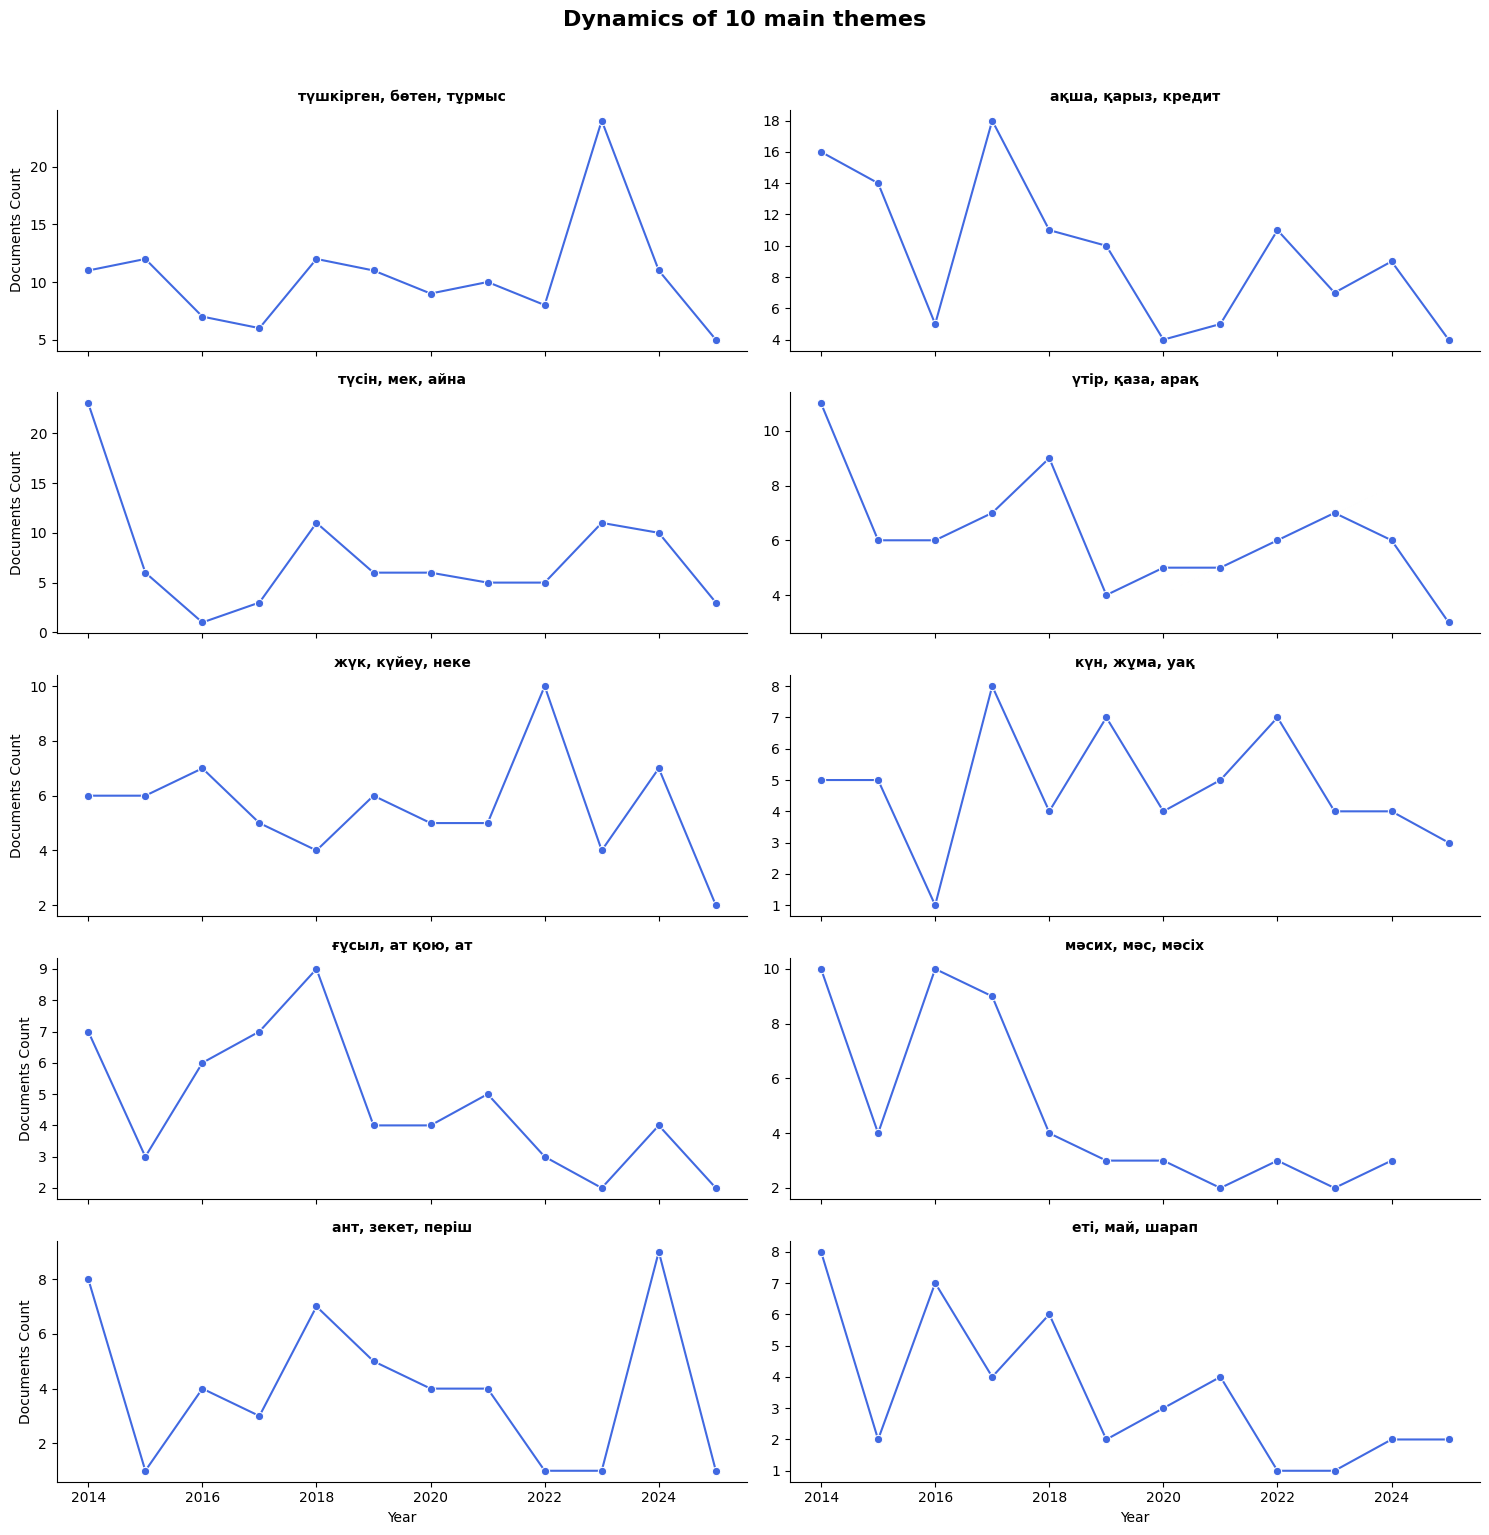

In [29]:
# 1. Группируем данные по темам и годам
df_all = df.groupby(['topic', 'year']).size().reset_index(name='Count')
df_all = df_all[df_all['topic'] != -1]

# 2. Вычисляем ТОП-10 тем по общему количеству
top_10_ids = df_all.groupby('topic')['Count'].sum().nlargest(10).index
df_top_10 = df_all[df_all['topic'].isin(top_10_ids)].copy()

# 3. Добавляем человекочитаемые названия тем
topic_words = {t: ", ".join([w[0] for w in model_bigrams.get_topic(t)[:3]]) for t in top_10_ids}
df_top_10['Topic_Name'] = df_top_10['topic'].map(topic_words)

# 4. Визуализация через FacetGrid
# Создаем сетку 5x2 (5 строк, 2 колонки)
g = sns.FacetGrid(df_top_10, col="Topic_Name", col_wrap=2, height=3, aspect=2.5, sharey=False)

# Рисуем линии
g.map(sns.lineplot, "year", "Count", marker='o', color='royalblue')

# 5. Оформление
g.set_titles("{col_name}", fontsize=11, fontweight='bold')
g.set_axis_labels("Year", "Documents Count")
g.fig.suptitle("Dynamics of 10 main themes", y=1.02, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# 1. Визуализация структуры тем (Thematic Landscape)

## Hierarchical Clustering

In [30]:

model_bigrams.visualize_hierarchy()

In [ ]:
model_bigrams.visualize_topics_over_time(topics_over_time)

In [ ]:
# Добавим вероятности к каждому документу
prob_df = pd.DataFrame(probabilities, columns=[f"Topic {i}" for i in range(probabilities.shape[1])])
prob_df['year'] = df['year'].values

# Усредняем вероятности тем по годам
avg_probs = prob_df.groupby('year').mean()

# Можно переименовать темы более понятно
topic_labels = {}
for t in range(len(avg_probs.columns)):
    words = model.get_topic(t)
    if words:
        topic_labels[f"Topic {t}"] = ", ".join([w[0] for w in words[:3]])
    else:
        topic_labels[f"Topic {t}"] = f"Topic {t}"

avg_probs.rename(columns=topic_labels, inplace=True)